# 1.3 Sistem Persamaan Linear (Systems of Linear Equations)

Sistem persamaan linear terdiri dari beberapa persamaan yang melibatkan sejumlah variabel, seperti:

$$
\begin{aligned}
a_{11}x_1 + a_{12}x_2 + \cdots + a_{1N}x_N &= b_1 \\
a_{21}x_1 + a_{22}x_2 + \cdots + a_{2N}x_N &= b_2 \\
\vdots \\
a_{M1}x_1 + a_{M2}x_2 + \cdots + a_{MN}x_N &= b_M
\end{aligned}
\tag{1.1}
$$

Bentuk ringkas sistem tersebut ditulis dengan notasi matriks-vektor:

$$
A_{M \times N} \cdot \mathbf{x} = \mathbf{b}
\tag{1.2}
$$

Dengan:

$$
A = 
\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1N} \\
a_{21} & a_{22} & \cdots & a_{2N} \\
\vdots & \vdots & \ddots & \vdots \\
a_{M1} & a_{M2} & \cdots & a_{MN}
\end{bmatrix}, \quad
\mathbf{x} = 
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_N
\end{bmatrix}, \quad
\mathbf{b} = 
\begin{bmatrix}
b_1 \\
b_2 \\
\vdots \\
b_M
\end{bmatrix}
\tag{1.3}
$$

---

## Tiga Kasus Sistem Linear

1. **M = N** (matriks persegi): jumlah persamaan sama dengan jumlah variabel, solusi eksak mungkin ada.  
2. **M < N** (underdetermined): jumlah persamaan lebih sedikit dari jumlah variabel, solusi tak hingga. Dicari solusi norma minimum.  
3. **M > N** (overdetermined): jumlah persamaan lebih banyak dari jumlah variabel, solusi eksak belum tentu ada. Gunakan pendekatan Least Squares.

---

## 1.3.1 Kasus Nonsingular (M = N)

Jika matriks \( A \) berbentuk persegi dan tidak singular, maka sistem memiliki solusi unik:

$$
\mathbf{x} = A^{-1} \cdot \mathbf{b}
\tag{1.3.1}
$$

### Penurunan Rumus

Mulai dari:

$$
A \cdot \mathbf{x} = \mathbf{b}
\tag{1.3.2}
$$

Kalikan kedua ruas dengan $ ( A^{-1}) $:

$$
A^{-1} \cdot A \cdot \mathbf{x} = A^{-1} \cdot \mathbf{b}
\tag{1.3.3}
$$

Karena:

$$
A^{-1} \cdot A = I
\tag{1.3.4}
$$

Maka:

$$
\mathbf{x} = A^{-1} \cdot \mathbf{b}
\tag{1.3.5}
$$


In [1]:
import numpy as np

A = np.array([[1, 2], [3, 4]])
b = np.array([-1, -1])
x = np.linalg.inv(A) @ b  # atau lebih efisien: x = np.linalg.solve(A, b)
print(x)


[ 1. -1.]


# 1.3.2 Underdetermined Case (M < N) — Minimum-Norm Solution

## Kondisi Awal

Jika jumlah persamaan \( M \) lebih kecil dari jumlah variabel \( N \), maka solusi dari sistem persamaan linear:

$$
A x = b \tag{1.3.6}
$$

tidak unik dan terdapat tak hingga banyak solusi.  
Namun, kita bisa mencari solusi dengan norma terkecil (*minimum-norm solution*).

## Tujuan

Mencari:

$$
x \text{ sedemikian sehingga } A x = b \text{ dan } \|x\| \text{ minimum}
$$

## Penurunan Rumus Minimum-Norm

Misalkan $ A^{M \times N} $ dengan $  M < N $ dan baris-baris $ A  $ saling independen.

### Langkah 1: Dekompisi Solusi

Vektor solusi \( x \) dipecah menjadi dua komponen ortogonal:

$$
x = x^+ + x^\circ \tag{1.3.7}
$$

- $ x^+ \in \mathcal{R}(A^T) $ : bagian dari *row space* $ A $  
- $ x^\circ \in \mathcal{N}(A) $ : bagian dari *null space* $ A $ , sehingga:

$$
A x^\circ = 0 \tag{1.3.8}
$$

### Langkah 2: Nyatakan $ x^+ $ dalam bentuk $ A^T \alpha $

Karena $ x^+ $ berada di row space, maka dapat dinyatakan:

$$
x^+ = A^T \alpha \tag{1.3.9}
$$

### Langkah 3: Substitusi ke Persamaan (1.3.6)

Substitusikan ke $ A x = b $:

$$
A x = A(x^+ + x^\circ) = A x^+ = b \tag{1.3.10}
$$

Substitusikan $ x^+ = A^T \alpha $:

$$
A A^T \alpha = b
$$

### Langkah 4: Selesaikan untuk $ alpha $

Misalkan $ A A^T $ invertibel, maka:

$$
\alpha = (A A^T)^{-1} b \tag{1.3.11}
$$

### Langkah 5: Substitusi ke $ x^+ $

Substitusi $ \alpha $ ke dalam ekspresi $ x^+ $:

$$
x^+ = A^T (A A^T)^{-1} b \tag{1.3.12}
$$

## Interpretasi

- $ x^+ $ adalah solusi dengan norma terkecil dari semua solusi $ x $ yang memenuhi $ A x = b $ 
- Komponen $ x^\circ $ merupakan bagian dari null space, dan tidak memengaruhi hasil $ A x $  
- Oleh karena itu, solusi umum adalah:

$$
x = x^+ + x^\circ
$$

Namun, hanya:

$$
x^+ = A^T (A A^T)^{-1} b
$$

yang memiliki norma terkecil dari semua solusi.

## Proyeksi dan Hubungan Geometris

Jika $ x^o $ adalah sembarang solusi dari $ A x = b $ , maka:

- Proyeksi $ x^o $ ke row space:

$$
x^+ = A^T (A A^T)^{-1} A x^o \tag{1.3.13}
$$

- Proyeksi $ x^o $ ke null space:

$$
x^\circ = x^o - x^+ = \left[ I - A^T (A A^T)^{-1} A \right] x^o \tag{1.3.14}
$$

- Sistem $ A x = b $ dengan $ M < N $ memiliki banyak solusi  
- Namun solusi *minimum-norm* dapat dihitung secara eksak dengan rumus:

$$
x^+ = A^T (A A^T)^{-1} b
$$

## Contoh 1.17 – Minimum-Norm Solution

Misalkan kita ingin menyelesaikan sistem persamaan linear:

$$
[1 \quad 2] \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = 3
\quad \text{dengan} \quad A = [1 \quad 2], \quad b = 3
\tag{1.3.15}
$$

### Penyelesaian Umum

Sistem ini memiliki tak hingga banyak solusi. Semua pasangan $x = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$ yang memenuhi:

$$
x_1 + 2x_2 = 3 \quad \text{atau} \quad x_2 = -\frac{1}{2}x_1 + \frac{3}{2}
\tag{1.3.16}
$$

adalah solusi yang valid. Ini membentuk sebuah **garis lurus** dalam ruang solusi.

---

### Vektor dalam Row Space

vektor dalam row space dari matriks $A$ dapat dituliskan sebagai:

$$
x^+ = A^T \alpha = \begin{bmatrix} 1 \\ 2 \end{bmatrix} \alpha
\quad \text{(karena $M = 1$, maka $\alpha$ adalah skalar)}
\tag{1.3.17}
$$

---

### Vektor dalam Null Space

vektor dalam null space dari $A$ adalah:

$$
A x^0 = [1 \quad 2] \begin{bmatrix} x_1^0 \\ x_2^0 \end{bmatrix} = 0
\Rightarrow x_1^0 + 2x_2^0 = 0 \Rightarrow x_2^0 = -\frac{1}{2} x_1^0
\tag{1.3.18}
$$

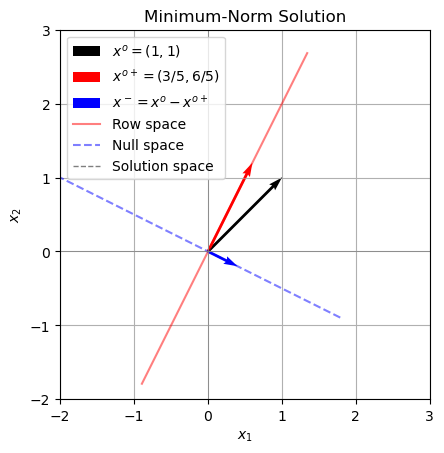

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Definisikan vektor-vektor
x_o = np.array([1, 1])
x_oplus = np.array([3/5, 6/5])
x_minus = x_o - x_oplus

# Buat plot
fig, ax = plt.subplots()
ax.set_aspect('equal')

# Fungsi untuk menggambar vektor dari titik asal
def plot_vector(v, color, label):
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy',
              scale=1, color=color, label=label)

# Gambar vektor-vektor
plot_vector(x_o, 'black', r'$x^o = (1,1)$')
plot_vector(x_oplus, 'red', r'$x^{o+} = (3/5, 6/5)$')
plot_vector(x_minus, 'blue', r'$x^- = x^o - x^{o+}$')

# Buat garis Row Space dan Null Space
x_vals = np.linspace(-2, 3, 100)

# Row space sepanjang vektor [1, 2]
row_dir = np.array([1, 2])
row_line = np.outer(x_vals, row_dir / np.linalg.norm(row_dir))
ax.plot(row_line[:, 0], row_line[:, 1], 'r-', alpha=0.5, label='Row space')

# Null space sepanjang vektor [-2, 1]
null_dir = np.array([-2, 1])
null_line = np.outer(x_vals, null_dir / np.linalg.norm(null_dir))
ax.plot(null_line[:, 0], null_line[:, 1], 'b--', alpha=0.5, label='Null space')

# Solution space (garis hitam dari origin ke x_o)
ax.plot([0, x_o[0]], [0, x_o[1]], 'k--', linewidth=1, alpha=0.5, label='Solution space')

# Setting sumbu dan grid
ax.set_xlim(-2, 3)
ax.set_ylim(-2, 3)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.grid(True)
ax.set_title("Minimum-Norm Solution")
ax.legend(loc='upper left')
plt.show()



### Solusi Minimum-Norm

Gunakan rumus minimum-norm

$$
x^+ = A^T (A A^T)^{-1} b
\tag{1.3.19}
$$

Substitusi nilai:

$$
x^+ =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\left(
[1 \quad 2]
\begin{bmatrix} 1 \\
2
\end{bmatrix}
\right)^{-1}
\cdot 3
=
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\cdot \frac{1}{5} \cdot 3
=
\frac{3}{5}
\begin{bmatrix}
1 \\
2
\end{bmatrix}
=
\begin{bmatrix}
0.6 \\
1.2
\end{bmatrix}
\tag{1.3.20}
$$

In [1]:
import numpy as np

# Definisi matriks A dan vektor b
A = np.array([[1, 2]])
b = 3

# Hitung solusi minimum-norm
x_plus = A.T @ np.linalg.inv(A @ A.T) @ np.array([[b]])

print("Solusi minimum-norm x+ =\n", x_plus)

Solusi minimum-norm x+ =
 [[0.6]
 [1.2]]


## 1.3.3 Kasus Overdetermined ($M > N$) – Least Squares Error (LSE) Solution

Jika jumlah persamaan $M$ lebih banyak daripada jumlah variabel $N$ (overdetermined system), maka **biasanya tidak ada solusi eksak** untuk semua persamaan. Oleh karena itu, kita mencari solusi yang **mendekati**:

### Tujuan:
Minimalkan norma dari vektor error:

$$
\mathbf{e} = A\mathbf{x} - \mathbf{b}
\tag{1.3.21}
$$

### Fungsi Objektif:

$$
J(\mathbf{x}) = \frac{1}{2} \|A\mathbf{x} - \mathbf{b}\|^2
= \frac{1}{2} (A\mathbf{x} - \mathbf{b})^T (A\mathbf{x} - \mathbf{b})
\tag{1.3.22}
$$

Turunkan terhadap $\mathbf{x}$:

$$
\frac{\partial J}{\partial \mathbf{x}} = A^T A \mathbf{x} - A^T \mathbf{b}
$$

Set gradien = 0 (untuk minimum):

$$
A^T A \mathbf{x} = A^T \mathbf{b}
$$

Selesaikan untuk $\mathbf{x}$:

$$
\boxed{
\mathbf{x}^o = (A^T A)^{-1} A^T \mathbf{b}
}
\tag{1.3.23}
$$

# Contoh 1.18 – Least Squares untuk Sistem Overdetermined

Misalkan sistem persamaan:

$$
A =
\begin{bmatrix}
1 & 1 \\
1 & 2 \\
1 & 3
\end{bmatrix}, \quad
\mathbf{b} =
\begin{bmatrix}
1 \\
2 \\
2
\end{bmatrix}
$$

Karena jumlah persamaan lebih banyak dari jumlah variabel ($M > N$), kita cari solusi **Least Squares**.

# Least Squares Method (Metode Kuadrat Terkecil)

## 1. Hitung $A^T A$ dan $A^T \mathbf{b}$

Misalkan matriks $A$ dan $\mathbf{b}$ adalah:

$$
A = \begin{bmatrix}
1 & 1 \\
1 & 2 \\
1 & 3
\end{bmatrix}, \quad
\mathbf{b} = \begin{bmatrix}
1 \\
2 \\
2
\end{bmatrix}
$$

Hitung:

$$
A^T A = \begin{bmatrix}
1 & 1 & 1 \\
1 & 2 & 3
\end{bmatrix}
\begin{bmatrix}
1 & 1 \\
1 & 2 \\
1 & 3
\end{bmatrix}
= \begin{bmatrix}
3 & 6 \\
6 & 14
\end{bmatrix}
$$

$$
A^T \mathbf{b} = \begin{bmatrix}
1 & 1 & 1 \\
1 & 2 & 3
\end{bmatrix}
\begin{bmatrix}
1 \\
2 \\
2
\end{bmatrix}
= \begin{bmatrix}
5 \\
12
\end{bmatrix}
$$

---

## 2. Hitung $\mathbf{x}^\circ = (A^T A)^{-1} A^T \mathbf{b}$

$$
(A^T A)^{-1} = \left( \begin{bmatrix}
3 & 6 \\
6 & 14
\end{bmatrix} \right)^{-1}
= \begin{bmatrix}
2.3333 & -1 \\
-1 & 0.5
\end{bmatrix}
$$

$$
\mathbf{x}^\circ = (A^T A)^{-1} A^T \mathbf{b}
= \begin{bmatrix}
2.3333 & -1 \\
-1 & 0.5
\end{bmatrix}
\begin{bmatrix}
5 \\
12
\end{bmatrix}
= \begin{bmatrix}
0.6667 \\
0.5
\end{bmatrix}
$$

---

## 3. Proyeksi ke $\hat{\mathbf{b}} = A \mathbf{x}^\circ$

$$
\hat{\mathbf{b}} = A \mathbf{x}^\circ = \begin{bmatrix}
1 & 1 \\
1 & 2 \\
1 & 3
\end{bmatrix}
\begin{bmatrix}
0.6667 \\
0.5
\end{bmatrix}
= \begin{bmatrix}
1.1667 \\
1.6667 \\
2.1667
\end{bmatrix}
$$

---

## Kesimpulan

Solusi hampiran (Least Squares) dari $A \mathbf{x} \approx \mathbf{b}$ adalah:

$$
\mathbf{x}^\circ = \begin{bmatrix}
0.6667 \\
0.5
\end{bmatrix}
$$

Dengan vektor hasil aproksimasi:

$$
\hat{\mathbf{b}} = \begin{bmatrix}
1.1667 \\
1.6667 \\
2.1667
\end{bmatrix}
$$

In [3]:
import numpy as np

# Matriks A dan vektor b
A = np.array([
    [1, 1],
    [1, 2],
    [1, 3]
])
b = np.array([1, 2, 2])

# Langkah 1: Hitung AtA dan Atb
AtA = A.T @ A
Atb = A.T @ b

# Langkah 2: Hitung solusi least squares
x_ls = np.linalg.inv(AtA) @ Atb

# Langkah 3: Hitung b_hat (proyeksi dari b)
b_hat = A @ x_ls

# Tampilkan hasil
print("Solusi Least Squares x^o:")
print(x_ls)

print("\nProyeksi b_hat = A x^o:")
print(b_hat)

Solusi Least Squares x^o:
[0.66666667 0.5       ]

Proyeksi b_hat = A x^o:
[1.16666667 1.66666667 2.16666667]


# 1.3.4 Eliminasi Gauss dengan Partial Pivoting

Metode **Eliminasi Gauss** digunakan untuk menyelesaikan sistem persamaan linear:

$$
A \mathbf{x} = \mathbf{b} \tag{1.3.14}
$$

dengan mengubah matriks \( A \) menjadi bentuk segitiga atas (*upper triangular*), kemudian menyelesaikan dengan substitusi balik (*back substitution*).

## Langkah-langkah Eliminasi Gauss

### 🔹 A. Forward Elimination

Mengeliminasi elemen-elemen di bawah diagonal utama untuk membentuk matriks segitiga atas.

**Rumus eliminasi:**

$$
a_{mn}^{(k)} = a_{mn}^{(k-1)} - \frac{a_{mk}^{(k-1)} \cdot a_{kn}^{(k-1)}}{a_{kk}^{(k-1)}} \tag{1.3.25}
$$

**Keterangan:**
- $ a_{mn}^{(k)} $ : elemen hasil pada iterasi ke- $ k $
- $ a_{kk} $ : pivot (elemen diagonal utama)
- $ m > k $ , $ n \geq k $

---

### 🔹 B. Backward Substitution

Setelah bentuk segitiga atas diperoleh, variabel diselesaikan dari bawah ke atas.

**Rumus substitusi balik:**

$$
x_m = \frac{b_m - \sum_{n=m+1}^{N} a_{mn} x_n}{a_{mm}} \tag{1.3.26}
$$
#### Keterangan:
- $ x_m $ : nilai variabel ke-$ m $ yang sedang dicari.  
- $ b_m $ : konstanta pada ruas kanan dari persamaan ke-$ m $.  
- $ a_{mn} $ : elemen matriks pada baris $ m $ dan kolom $ n $.  
- $ x_n $ :$ variabel yang sudah diketahui dari baris di bawahnya (karena proses dari bawah ke atas).  
- $ a_{mm} $ : elemen diagonal utama pada baris $ m $.  
- $ N $ : jumlah variabel dalam sistem persamaan.
---

## Partial Pivoting

### 🔸 Masalah

Jika elemen pivot $ a_{kk} $ sangat kecil atau nol, maka dapat menyebabkan pembagian tidak stabil atau tak terdefinisi.

### 🔸 Solusi: Partial Pivoting

Tukar baris ke- $ k $ dengan baris di bawahnya yang memiliki elemen terbesar (nilai absolut) di kolom ke- $ k $.



## Sistem Persamaan Linear

Diberikan sistem persamaan:

$$
\begin{aligned}
0x_1 + 1x_2 + 1x_3 &= 2 \\
2x_1 - 1x_2 - 1x_3 &= 0 \\
1x_1 - 1x_2 + 1x_3 &= 1
\end{aligned}
$$

## Matriks Augmented

Gabungkan menjadi:

$$
\begin{bmatrix}
0 & 1 & 1 & | & 2 \\
2 & -1 & -1 & | & 0 \\
1 & -1 & 1 & | & 1
\end{bmatrix}
$$

## Pivot Parsial

Karena elemen pertama kolom pertama adalah nol, lakukan pertukaran baris agar elemen pivot terbesar ada di posisi atas:

$$
\begin{bmatrix}
2 & -1 & -1 & | & 0 \\
0 & 1 & 1 & | & 2 \\
1 & -1 & 1 & | & 1
\end{bmatrix}
$$

## Eliminasi Baris (Langkah 1)

Baris ke-3:
$$
\text{Baris 3} \leftarrow \text{Baris 3} - \frac{1}{2} \times \text{Baris 1}
$$

Hasil:

$$
\begin{bmatrix}
2 & -1 & -1 & | & 0 \\
0 & 1 & 1 & | & 2 \\
0 & -0.5 & 1.5 & | & 1
\end{bmatrix}
$$

## Pertukaran Baris (Langkah 2)

Tukar baris 2 dan 3 (karena $|-0.5| > |1|$):

$$
\begin{bmatrix}
2 & -1 & -1 & | & 0 \\
0 & -0.5 & 1.5 & | & 1 \\
0 & 1 & 1 & | & 2
\end{bmatrix}
$$

## Eliminasi Baris (Langkah 3)

Baris ke-3:
$$
\text{Baris 3} \leftarrow \text{Baris 3} + 2 \times \text{Baris 2}
$$

Hasil:

$$
\begin{bmatrix}
2 & -1 & -1 & | & 0 \\
0 & -0.5 & 1.5 & | & 1 \\
0 & 0 & 4 & | & 4
\end{bmatrix}
$$

## Backward Substitution

Dari hasil akhir:

$$
\begin{aligned}
x_3 &= \frac{4}{4} = 1 \\
x_2 &= \frac{1 - 1.5 \cdot x_3}{-0.5} = \frac{1 - 1.5}{-0.5} = 1 \\
x_1 &= \frac{0 + x_2 + x_3}{2} = \frac{1 + 1}{2} = 1
\end{aligned}
$$

### Solusi:
$$
\mathbf{x} = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}
$$

## Kasus Redundansi

Contoh sistem:

$$
\begin{bmatrix}
1 & 1 & 1 & | & 3 \\
0 & 1 & 1 & | & 2 \\
0 & 0 & 0 & | & 0
\end{bmatrix}
$$

Baris ketiga adalah nol total → sistem memiliki tak hingga solusi.

Solusi umum:
$$
\mathbf{x} = \begin{bmatrix} 2 \\ 1 \\ 0 \end{bmatrix} + x_3 \cdot \begin{bmatrix} -1 \\ -1 \\ 1 \end{bmatrix}
$$

## Kasus Inkonsistensi

Jika sistem menjadi:

$$
\begin{bmatrix}
1 & 1 & 1 & | & 3 \\
0 & 1 & 1 & | & 2 \\
0 & 0 & 0 & | & 2
\end{bmatrix}
$$

Maka baris ketiga menyatakan:

$$
0 = 2 \Rightarrow \text{tidak konsisten} \Rightarrow \text{tidak ada solusi}
$$

In [2]:
import numpy as np

def gauss_elimination_partial_pivot(A, B):
    """
    Menyelesaikan Ax = B menggunakan eliminasi Gauss dengan pivot parsial.
    A: matriks koefisien (n x n)
    B: vektor hasil (n x 1)
    """
    A = A.astype(float)
    B = B.astype(float)
    N = len(B)

    # Membentuk matriks augmented
    AB = np.hstack((A, B.reshape(-1, 1)))

    # Forward elimination dengan partial pivoting
    for k in range(N - 1):
        # Partial pivoting: cari baris dengan elemen terbesar di kolom k
        max_row = np.argmax(np.abs(AB[k:, k])) + k
        if AB[max_row, k] == 0:
            raise ValueError("Pivot nol: sistem tidak bisa diselesaikan.")
        # Tukar baris
        if max_row != k:
            AB[[k, max_row]] = AB[[max_row, k]]
        
        # Eliminasi ke bawah
        for i in range(k + 1, N):
            m = AB[i, k] / AB[k, k]
            AB[i, k:] -= m * AB[k, k:]

    # Backward substitution
    x = np.zeros(N)
    for i in range(N - 1, -1, -1):
        x[i] = (AB[i, -1] - np.dot(AB[i, i+1:N], x[i+1:N])) / AB[i, i]

    return x

# Contoh penggunaan:
A = np.array([[0, 1, 1],
              [2, -1, -1],
              [1, -1, 1]], dtype=float)

B = np.array([2, 0, 1], dtype=float)

solusi = gauss_elimination_partial_pivot(A, B)
print("Solusi SPL:", solusi)


Solusi SPL: [1. 1. 1.]


# 1.3.5 Recursive Least Squares (RLS) Algorithm

## Tujuan

Metode **Recursive Least Squares (RLS)** digunakan untuk mengestimasi parameter dari model linier secara *recursive* (berulang) ketika data masuk satu per satu (*online*). Tujuannya adalah untuk menghindari komputasi ulang dari awal seperti pada metode Least Squares biasa.

## Model

Model linier dasar:

$$
c_1 \cdot t + c_2 = r
$$

dengan:
- $ t $ : temperatur,
- $ r $ : resistansi (Ω),
- $ c_1, c_2 $: parameter yang ingin diestimasi.

Jika ada $ k $ data pengamatan $ \{(t_1, r_1), ..., (t_k, r_k)\} $, maka dapat dituliskan sebagai sistem linier:

$$
A_k x_k \approx b_k \tag{1.3.27}
$$

dengan:

$$
A_k =
\begin{bmatrix}
t_1 & 1 \\
t_2 & 1 \\
\vdots & \vdots \\
t_k & 1
\end{bmatrix}, \quad
x_k =
\begin{bmatrix}
c_1 \\
c_2
\end{bmatrix}, \quad
b_k =
\begin{bmatrix}
r_1 \\
r_2 \\
\vdots \\
r_k
\end{bmatrix}
$$

## Solusi Least Squares (Batch)

Jika semua data tersedia:

$$
x_k = (A_k^T A_k)^{-1} A_k^T b_k \tag{1.3.28}
$$

Namun ini tidak efisien jika data datang satu per satu karena harus menghitung invers matriks dari awal setiap kali.

## Menambahkan Data Baru Secara Rekursif

Jika data baru $ (t_{k+1}, r_{k+1}) $ masuk, maka:

$$
A_{k+1} =
\begin{bmatrix}
A_k \\
a_{k+1}^T
\end{bmatrix}, \quad
b_{k+1} =
\begin{bmatrix}
b_k \\
r_{k+1}
\end{bmatrix}
$$

dengan:

$$
a_{k+1} =
\begin{bmatrix}
t_{k+1} \\
1
\end{bmatrix}
$$

## Matrix Inversion Lemma

Untuk memperbarui $ P_k = (A_k^T A_k)^{-1} $ tanpa menghitung ulang invers:

$$
P_{k+1} = P_k - \frac{P_k a_{k+1} a_{k+1}^T P_k}{1 + a_{k+1}^T P_k a_{k+1}} \tag{1.3.29}
$$

## Update Estimasi Parameter

Hitung *gain matrix*:

$$
K_{k+1} = \frac{P_k a_{k+1}}{1 + a_{k+1}^T P_k a_{k+1}} \tag{1.3.30}
$$

Update parameter:

$$
x_{k+1} = x_k + K_{k+1} (r_{k+1} - a_{k+1}^T x_k) \tag{1.3.31}
$$

Update matriks kovariansi:

$$
P_{k+1} = P_k - K_{k+1} a_{k+1}^T P_k \tag{1.3.32}
$$

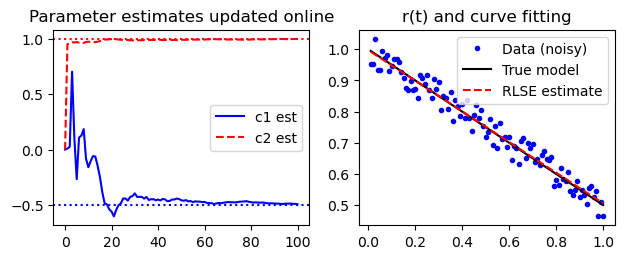

Hasil estimasi RLSE terakhir (x_on):
[-0.49168592  0.99733928]
Hasil estimasi Least Squares (x1):
[-0.49180538  0.99740958]
Parameter sebenarnya (x0):
[-0.5  1. ]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fungsi RLSE satu langkah
def RLSE_online(a_k, b_k, x, P):
    a_k = a_k.reshape(-1, 1)
    b_k = np.array([[b_k]])
    K = P @ a_k / (1 + a_k.T @ P @ a_k)
    x_new = x + K @ (b_k - a_k.T @ x)
    P_new = P - K @ a_k.T @ P
    return x_new, P_new

# Nilai parameter sebenarnya
x0 = np.array([[-0.5], [1.0]])
NA = x0.shape[0]      # Dimensi parameter
kmax = 100            # Jumlah data
t = 0.01 * np.arange(1, kmax+1)  # Data suhu / waktu

# Inisialisasi
xk = np.zeros((NA, kmax + 1))   # Estimasi awal
P = 1000 * np.eye(NA)           # Kovariansi awal besar
r = np.zeros(kmax)
A = np.zeros((kmax, NA))

# Iterasi RLSE
for k in range(kmax):
    A[k, :] = [t[k], 1]
    r[k] = A[k, :] @ x0[:, 0] + 0.1 * (np.random.rand() - 0.5)  # Eq (1.3.44)
    x_prev = xk[:, [k]]   # Estimasi sebelumnya (kolom)
    x_new, P = RLSE_online(A[k, :], r[k], x_prev, P)
    xk[:, k+1] = x_new[:, 0]

# Estimasi offline (Least Squares)
x1 = np.linalg.pinv(A.T @ A) @ A.T @ r    # Eq (1.3.13)

# Estimasi terakhir (RLSE online)
x_on = xk[:, -1]

# Plot 1: Estimasi parameter terhadap iterasi
plt.subplot(2, 2, 1)
plt.plot(xk[0, :], 'b', label='c1 est')
plt.plot(xk[1, :], 'r--', label='c2 est')
plt.axhline(y=x0[0, 0], color='b', linestyle=':')
plt.axhline(y=x0[1, 0], color='r', linestyle=':')
plt.title('Parameter estimates updated online')
plt.legend()

# Plot 2: Kurva fitting
plt.subplot(2, 2, 2)
plt.plot(t, r, 'b.', label='Data (noisy)')
plt.plot(t, A @ x0, 'k-', label='True model')
plt.plot(t, A @ x_on.reshape(-1, 1), 'r--', label='RLSE estimate')
plt.title('r(t) and curve fitting')
plt.legend()

plt.tight_layout()
plt.show()

# Tampilkan hasil akhir
print("Hasil estimasi RLSE terakhir (x_on):")
print(x_on)
print("Hasil estimasi Least Squares (x1):")
print(x1)
print("Parameter sebenarnya (x0):")
print(x0.flatten())
